# Proyek Analisis Data: Bike-sharing-dataset
- **Nama:** Muhammad Ibnu Rozaki
- **Email:** cdcc133d6y0083@student.devacademy.id
- **ID Dicoding:** muhammad_ibnu_rozaki

---
## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Kondisi cuaca dan musim apa yang menghasilkan rata-rata peminjaman sepeda harian tertinggi dan terendah pada sistem bike-sharing Capital Bikeshare di Washington D.C. selama periode tahun 2011–2012?
- **Pertanyaan 2:** Pada jam berapa puncak peminjaman sepeda terjadi dalam sehari, dan seberapa besar perbedaan volume peminjaman antara hari kerja dan hari libur/akhir pekan pada sistem Capital Bikeshare Washington D.C. selama periode tahun 2011–2012?

---
## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

---
## Data Wrangling

### Gathering Data

#### Load df day.csv dan hour.csv

In [2]:
# Load kedua dataset
day_df  = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')

print('=' * 40, 'day.csv', '=' * 40)
print(f'Shape : {day_df.shape}')
print(day_df.head())

print('\n', '=' * 40, 'hour.csv', '=' * 40)
print(f'Shape : {hour_df.shape}')
print(hour_df.head())

======================================== day.csv ========================================
Shape : (731, 16)
   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900   

**Insight:**
- Dataset `day.csv` memiliki 731 baris dan 16 kolom, mencakup data dari 1 Januari 2011 hingga 31 Desember 2012.
- Dataset `hour.csv` memiliki 17.379 baris dan 17 kolom, dengan tambahan kolom `hr` dibanding `day.csv`.

### Assessing Data

#### Identifying missing values, duplicates, and data type problems

In [3]:
# Cek tipe data
print('=== Tipe Data day_df ===')
print(day_df.dtypes)
print('\n=== Tipe Data hour_df ===')
print(hour_df.dtypes)

# Cek missing values
print('\n=== Missing Values day_df ===')
print(day_df.isnull().sum())
print('\n=== Missing Values hour_df ===')
print(hour_df.isnull().sum())

# Cek duplikat
print(f'\nDuplikat day_df  : {day_df.duplicated().sum()}')
print(f'Duplikat hour_df : {hour_df.duplicated().sum()}')

# --- Statistik deskriptif ---
print('\n=== Statistik Deskriptif day_df ===')
print(day_df.describe())

=== Tipe Data day_df ===
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

=== Tipe Data hour_df ===
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

=== Missing Values day_df ===
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
ate

**Insight:**
- Tidak ditemukan missing values maupun data duplikat pada kedua dataset, sehingga data cukup bersih.
- Kolom `dteday` masih bertipe `object` (string) dan perlu dikonversi ke tipe `datetime`. Kolom kategorikal seperti `season` dan `weathersit` masih berupa angka sehingga perlu di-mapping ke label yang lebih deskriptif.

### Cleaning Data

#### Fixing data type and categorical label problems

In [4]:
# 1. Konversi kolom tanggal
day_df['dteday']  = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# 2. Mapping kolom kategorikal
season_map     = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weathersit_map = {
    1: 'Clear',
    2: 'Mist/Cloudy',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
}
yr_map      = {0: 2011, 1: 2012}
weekday_map = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}

for df in [day_df, hour_df]:
    df['season_label']     = df['season'].map(season_map)
    df['weather_label']    = df['weathersit'].map(weathersit_map)
    df['yr_label']         = df['yr'].map(yr_map)
    df['weekday_label']    = df['weekday'].map(weekday_map)

# 3. Denormalisasi nilai cuaca
for df in [day_df, hour_df]:
    df['temp_actual']      = df['temp']      * 41    # Celsius
    df['atemp_actual']     = df['atemp']     * 50    # Celsius
    df['hum_actual']       = df['hum']       * 100   # Persen
    df['windspeed_actual'] = df['windspeed'] * 67    # km/h

print('Cleaning selesai. Kolom day_df setelah cleaning:')
print(day_df.columns.tolist())
print('\nSample data day_df:')
print(day_df[['dteday', 'season_label', 'weather_label', 'temp_actual', 'cnt']].head())

Cleaning selesai. Kolom day_df setelah cleaning:
['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt', 'season_label', 'weather_label', 'yr_label', 'weekday_label', 'temp_actual', 'atemp_actual', 'hum_actual', 'windspeed_actual']

Sample data day_df:
      dteday season_label weather_label  temp_actual   cnt
0 2011-01-01       Spring   Mist/Cloudy    14.110847   985
1 2011-01-02       Spring   Mist/Cloudy    14.902598   801
2 2011-01-03       Spring         Clear     8.050924  1349
3 2011-01-04       Spring         Clear     8.200000  1562
4 2011-01-05       Spring         Clear     9.305237  1600


**Insight:**
- Kolom `dteday` berhasil dikonversi ke tipe `datetime`, memudahkan analisis berbasis waktu.
- Kolom kategorikal (`season`, `weathersit`, `yr`, `weekday`) telah diberi label deskriptif sehingga lebih mudah dibaca saat visualisasi.
- Nilai suhu, kelembapan, dan kecepatan angin telah didenormalisasi ke satuan aslinya (°C, %, km/h).

## Exploratory Data Analysis (EDA)

### Explore Pengaruh Musim & Cuaca terhadap Peminjaman Harian

In [5]:
# Rata-rata peminjaman per musim
season_avg = day_df.groupby('season_label')['cnt'].mean().reindex(['Spring', 'Summer', 'Fall', 'Winter'])
print('=== Rata-rata Peminjaman per Musim ===')
print(season_avg.round(0))

# Rata-rata peminjaman per kondisi cuaca
weather_avg = day_df.groupby('weather_label')['cnt'].mean()
print('\n=== Rata-rata Peminjaman per Kondisi Cuaca ===')
print(weather_avg.round(0))

# Korelasi numerik
corr_cols = ['temp_actual', 'atemp_actual', 'hum_actual', 'windspeed_actual', 'cnt']
print('\n=== Korelasi terhadap cnt ===')
print(day_df[corr_cols].corr()['cnt'].drop('cnt').round(3))

=== Rata-rata Peminjaman per Musim ===
season_label
Spring    2604.0
Summer    4992.0
Fall      5644.0
Winter    4728.0
Name: cnt, dtype: float64

=== Rata-rata Peminjaman per Kondisi Cuaca ===
weather_label
Clear              4877.0
Light Rain/Snow    1803.0
Mist/Cloudy        4036.0
Name: cnt, dtype: float64

=== Korelasi terhadap cnt ===
temp_actual         0.627
atemp_actual        0.631
hum_actual         -0.101
windspeed_actual   -0.235
Name: cnt, dtype: float64


**Insight:**
- Musim **Fall (gugur)** memiliki rata-rata peminjaman tertinggi, diikuti Summer, Winter, dan terendah Spring. Ini menunjukkan cuaca sedang (tidak terlalu panas/dingin) lebih disukai pengguna.
- Kondisi cuaca **Clear** menghasilkan peminjaman jauh lebih tinggi dibanding cuaca buruk. Cuaca `Light Rain/Snow` menurunkan peminjaman secara signifikan.
- Suhu (`temp_actual`, `atemp_actual`) berkorelasi **positif** dengan jumlah peminjaman, sedangkan kelembapan (`hum_actual`) dan kecepatan angin (`windspeed_actual`) berkorelasi **negatif**.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca dan musim terhadap jumlah peminjaman sepeda harian?

/tmp/ipykernel_1272/3738636529.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


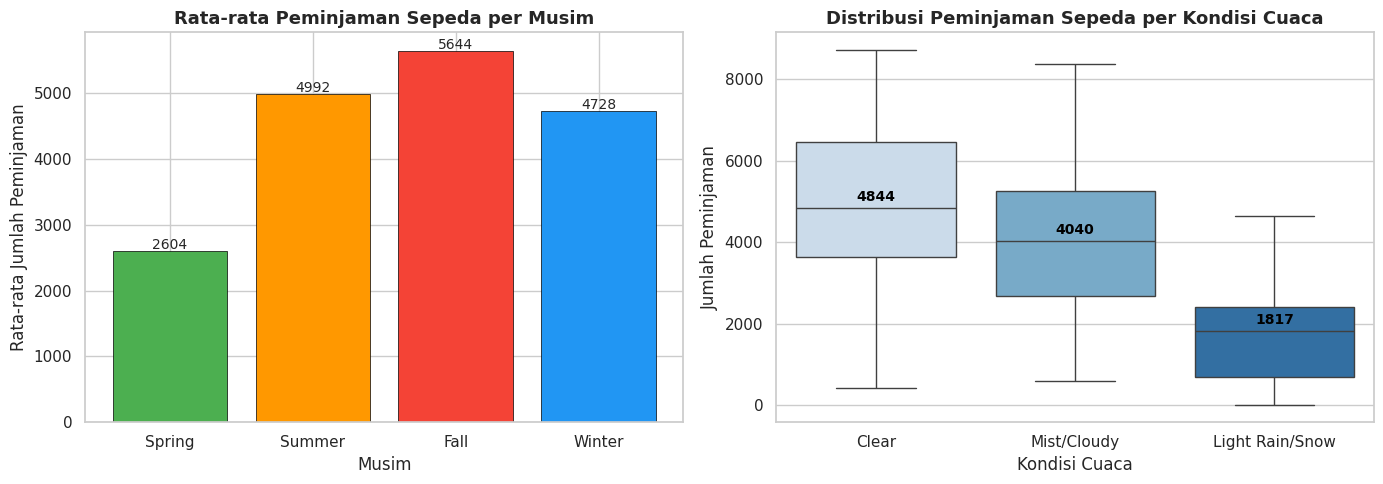

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Rata-rata peminjaman per musim
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_avg_plot = day_df.groupby('season_label')['cnt'].mean().reindex(season_order)
colors_season = ['#4CAF50', '#FF9800', '#F44336', '#2196F3']
axes[0].bar(season_avg_plot.index, season_avg_plot.values, color=colors_season, edgecolor='black', linewidth=0.5)
axes[0].set_title('Rata-rata Peminjaman Sepeda per Musim', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Musim')
axes[0].set_ylabel('Rata-rata Jumlah Peminjaman')
for i, v in enumerate(season_avg_plot.values):
    axes[0].text(i, v + 30, f'{v:.0f}', ha='center', fontsize=10)

# Plot 2: Boxplot peminjaman per kondisi cuaca
weather_order = ['Clear', 'Mist/Cloudy', 'Light Rain/Snow']
weather_data  = day_df[day_df['weather_label'].isin(weather_order)]
sns.boxplot(
    data=weather_data, x='weather_label', y='cnt',
    order=weather_order, palette='Blues', ax=axes[1]
)
medians = day_df.groupby('weather_label')['cnt'].median().reindex(weather_order).values

for i, median in enumerate(medians):
    axes[1].text(
        i, median + 100, f'{median:.0f}',
        ha='center', va='bottom',
        fontweight='bold', color='black', fontsize=10
    )
axes[1].set_title('Distribusi Peminjaman Sepeda per Kondisi Cuaca', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Kondisi Cuaca')
axes[1].set_ylabel('Jumlah Peminjaman')

plt.tight_layout()
plt.savefig('plot_pertanyaan1.png', dpi=150, bbox_inches='tight')
plt.show()

### Pertanyaan 2: Pada jam berapa puncak peminjaman terjadi, dan apakah berbeda antara hari kerja dan hari libur?

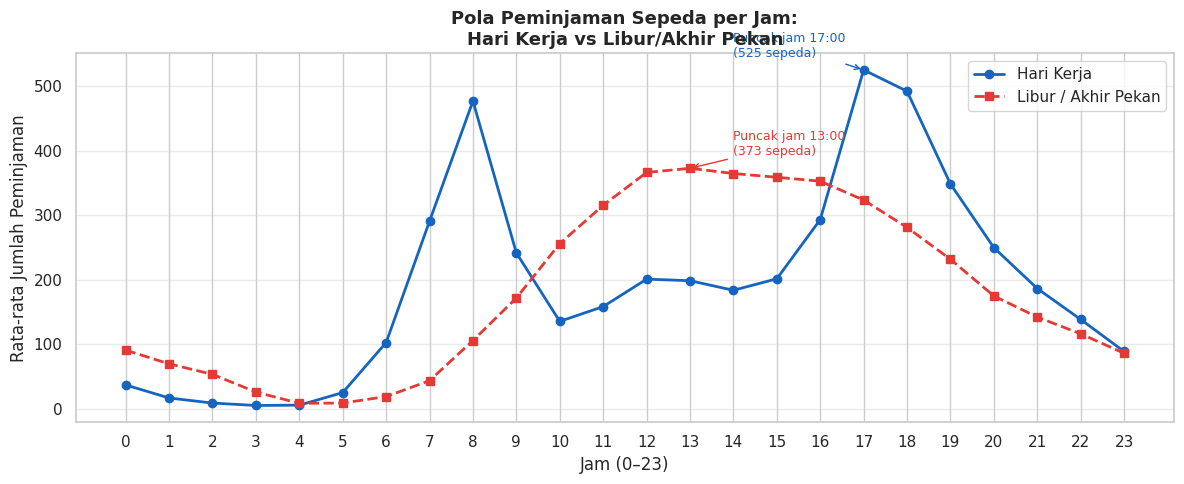

In [7]:
# Pisahkan data hari kerja dan hari libur/akhir pekan
workday_hourly  = hour_df[hour_df['workingday'] == 1].groupby('hr')['cnt'].mean()
holiday_hourly  = hour_df[hour_df['workingday'] == 0].groupby('hr')['cnt'].mean()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(workday_hourly.index,  workday_hourly.values,  marker='o', linewidth=2,
        color='#1565C0', label='Hari Kerja')
ax.plot(holiday_hourly.index, holiday_hourly.values, marker='s', linewidth=2,
        color='#E53935', linestyle='--', label='Libur / Akhir Pekan')

# Tandai puncak masing-masing
peak_work = workday_hourly.idxmax()
peak_holi = holiday_hourly.idxmax()
ax.annotate(f'Puncak jam {peak_work}:00\n({workday_hourly[peak_work]:.0f} sepeda)',
            xy=(peak_work, workday_hourly[peak_work]),
            xytext=(peak_work - 3, workday_hourly[peak_work] + 20),
            arrowprops=dict(arrowstyle='->', color='#1565C0'),
            fontsize=9, color='#1565C0')
ax.annotate(f'Puncak jam {peak_holi}:00\n({holiday_hourly[peak_holi]:.0f} sepeda)',
            xy=(peak_holi, holiday_hourly[peak_holi]),
            xytext=(peak_holi + 1, holiday_hourly[peak_holi] + 20),
            arrowprops=dict(arrowstyle='->', color='#E53935'),
            fontsize=9, color='#E53935')

ax.set_title('Pola Peminjaman Sepeda per Jam:\nHari Kerja vs Libur/Akhir Pekan', fontsize=13, fontweight='bold')
ax.set_xlabel('Jam (0–23)')
ax.set_ylabel('Rata-rata Jumlah Peminjaman')
ax.set_xticks(range(0, 24))
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('plot_pertanyaan2.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- **Hari kerja** memperlihatkan pola dua puncak (*bimodal*): jam **08:00** (berangkat kerja) dan jam **17:00–18:00** (pulang kerja), yang mengindikasikan sepeda digunakan sebagai moda komuter.
- **Hari libur/akhir pekan** memiliki satu puncak tunggal pada sekitar jam **13:00–14:00** dengan kenaikan yang lebih landai, mencerminkan penggunaan rekreasi di siang hari.
- Pola ini menunjukkan bahwa segmentasi pengguna sangat berbeda: pengguna *registered* cenderung dominan pada hari kerja (komuter), sementara pengguna *casual* lebih aktif di akhir pekan.

## Analisis Lanjutan (Opsional)

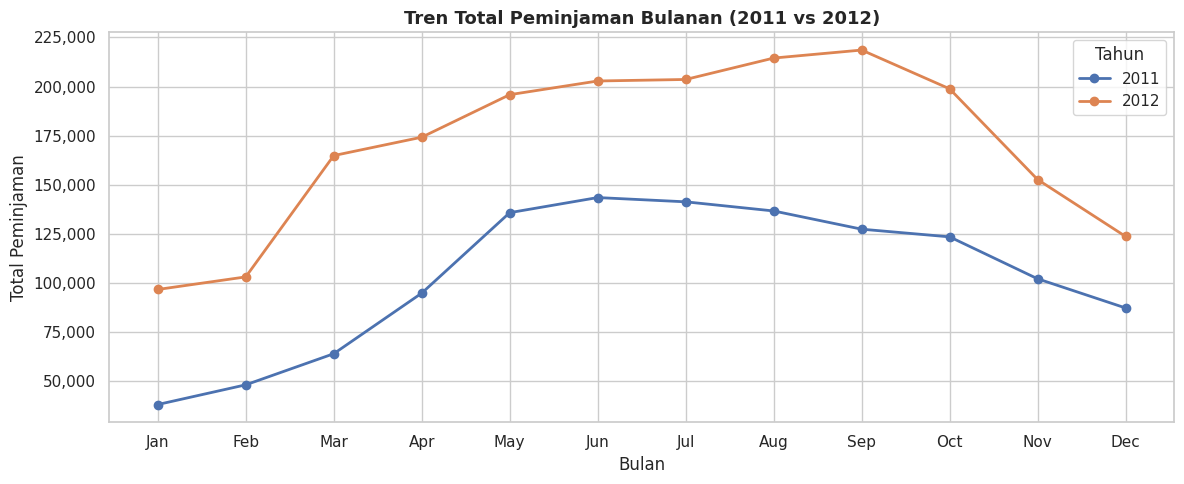

Total peminjaman per tahun:
yr_label
2011    1243103
2012    2049576
Name: cnt, dtype: int64

Pertumbuhan 2011→2012: 64.9%


In [8]:
# Tren peminjaman bulanan selama 2 tahun
monthly_trend = day_df.groupby(['yr_label', 'mnth'])['cnt'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
for yr, grp in monthly_trend.groupby('yr_label'):
    ax.plot(grp['mnth'], grp['cnt'], marker='o', linewidth=2, label=str(yr))

ax.set_title('Tren Total Peminjaman Bulanan (2011 vs 2012)', fontsize=13, fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Total Peminjaman')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend(title='Tahun')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('plot_trend_bulanan.png', dpi=150, bbox_inches='tight')
plt.show()

# Ringkasan pertumbuhan
total_per_yr = day_df.groupby('yr_label')['cnt'].sum()
print('Total peminjaman per tahun:')
print(total_per_yr)
growth = (total_per_yr[2012] - total_per_yr[2011]) / total_per_yr[2011] * 100
print(f'\nPertumbuhan 2011→2012: {growth:.1f}%')

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Musim dan cuaca berpengaruh signifikan terhadap jumlah peminjaman sepeda. Musim Fall (gugur) menghasilkan rata-rata peminjaman tertinggi, sementara musim Spring terendah. Kondisi cuaca cerah (Clear) mendorong peminjaman jauh lebih tinggi dibanding kondisi berkabut atau hujan. Suhu memiliki korelasi positif terhadap peminjaman, sedangkan kelembapan dan kecepatan angin berkorelasi negatif. Artinya, pengguna cenderung meminjam sepeda lebih banyak saat cuaca nyaman dan tidak berangin.

- **Conclusion pertanyaan 2:** Pola peminjaman per jam berbeda secara jelas antara hari kerja dan hari libur. Pada hari kerja, terdapat dua puncak di pagi (08:00) dan sore hari (17:00–18:00) yang mencerminkan penggunaan sepeda sebagai moda komuter. Pada hari libur/akhir pekan, terdapat satu puncak di siang hari (13:00–14:00) yang mencerminkan penggunaan rekreasi. Hal ini menunjukkan pentingnya menyediakan ketersediaan armada sepeda yang memadai pada jam-jam puncak tersebut sesuai tipe harinya.

**Rekomendasi Action Item:**
- Tingkatkan ketersediaan armada sepeda pada musim Fall dan Summer, serta pastikan pengurangan armada (atau promosi khusus) saat musim Spring untuk efisiensi operasional.
- Prioritaskan ketersediaan sepeda di stasiun-stasiun komuter pada jam 07:00–09:00 dan 16:00–18:00 di hari kerja, serta di area rekreasi/taman pada jam 11:00–15:00 di akhir pekan.
- Pertimbangkan program diskon atau insentif di hari-hari hujan/berkabut untuk menjaga volume peminjaman tetap stabil meski cuaca kurang mendukung.